### **PROJEK EAS STATKOM - NADIA SITI RAMADHANI**

In [79]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm

### Import Library

Sebelum melakukan analisis data, terlebih dahulu dilakukan pemanggilan beberapa library Python yang diperlukan untuk mendukung proses komputasi dan visualisasi. Library NumPy digunakan untuk pembangkitan data acak dan operasi numerik, Pandas digunakan untuk pengolahan data dalam bentuk tabel, Matplotlib dan Seaborn digunakan untuk membuat berbagai grafik visualisasi, SciPy digunakan untuk melakukan pengujian statistik, sedangkan Statsmodels digunakan untuk membangun model regresi linear dan menghasilkan parameter-parameter statistik yang diperlukan dalam analisis.

Dengan menggunakan library tersebut, proses pembangkitan data, analisis regresi, pengujian distribusi, serta visualisasi data dapat dilakukan secara lebih efisien dan terstruktur.


 **1. BANGKITKAN DATA X DAN Y**

Rumus Distribusi Normal:

$$
X \sim N(\mu, \sigma^2)
$$

Fungsi kepadatan probabilitas:

$$
f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$

Keterangan:
- μ = mean (rata-rata)  
- σ = standar deviasi


Rumus Distribusi Uniform:

$$
Y \sim U(a, b)
$$

Fungsi kepadatan probabilitas:

$$
f(x) = \frac{1}{b-a}, \quad a \le x \le b
$$

Keterangan:
- a = batas bawah  
- b = batas atas  
- Semua nilai dalam interval [a, b] memiliki peluang yang sama

In [80]:
# Menetapkan seed agar hasil selalu sama setiap dijalankan
np.random.seed(123)

# Membangkitkan 1000 data X berdistribusi Normal
X = np.random.normal(loc=50, scale=10, size=1000)

# Membangkitkan 1000 data Y berdistribusi Uniform
Y = np.random.uniform(low=0, high=100, size=1000)

# Membuat DataFrame
data_xy = pd.DataFrame({
    'X': X,
    'Y': Y
})
data_xy

,X,Y
0,39.143694,74.220923
1,59.973454,18.045347
2,52.829785,22.194477
3,34.937053,69.980925
4,44.213997,79.450432
...,...,...
995,56.347631,49.631273
996,60.699186,46.601611
997,40.906730,11.886731
998,54.702637,12.589755


Masing-masing library memiliki fungsi yang berbeda sesuai dengan kebutuhan analisis. NumPy (numpy) digunakan untuk melakukan pembangkitan data acak dari distribusi Normal dan Uniform serta mendukung berbagai operasi numerik. Pandas (pandas) digunakan untuk mengelola data dalam bentuk tabel sehingga memudahkan proses pengolahan dan analisis data.
Selanjutnya, Matplotlib (matplotlib.pyplot) dan Seaborn (seaborn) digunakan untuk membuat berbagai visualisasi data, seperti histogram, scatter plot, density plot, Q-Q Plot, boxplot, serta grafik regresi. Visualisasi tersebut bertujuan untuk memberikan gambaran mengenai karakteristik data dan hubungan antarvariabel secara lebih mudah dipahami.
Untuk proses pengujian statistik, digunakan SciPy (scipy.stats) yang menyediakan berbagai metode analisis, seperti uji Kolmogorov-Smirnov, Anderson-Darling, Shapiro-Wilk, Chi-Square, serta perhitungan korelasi Pearson. Sementara itu, Statsmodels (statsmodels.api) digunakan untuk membangun model regresi linear sederhana dan menghasilkan berbagai parameter statistik, seperti koefisien regresi, nilai t-statistik, F-statistik, p-value, dan koefisien determinasi (R²).
Penggunaan kombinasi library tersebut memungkinkan seluruh proses analisis pada proyek Statistika Komputasi dilakukan secara terintegrasi, mulai dari pembangkitan data, analisis statistik, visualisasi, hingga interpretasi hasil yang diperoleh


In [81]:
print(data_xy.describe())

                 X            Y
count  1000.000000  1000.000000
mean     49.604359    50.191323
std      10.012883    29.265378
min      17.689450     0.013594
25%      43.154434    24.454018
50%      49.588144    50.120512
75%      56.688657    76.259107
max      85.715792    99.964425


In [82]:
print("=" * 40)
print("STATISTIK DESKRIPTIF X".center(40))
print("=" * 40)

print("Mean            :", np.mean(X))
print("Median          :", np.median(X))
print("Varians         :", np.var(X, ddof=1))
print("Standar Deviasi :", np.std(X, ddof=1))
print("Minimum         :", np.min(X))
print("Maximum         :", np.max(X))

print("=" * 40)
print("STATISTIK DESKRIPTIF Y".center(40))
print("=" * 40)

print("Mean            :", np.mean(Y))
print("Median          :", np.median(Y))
print("Varians         :", np.var(Y, ddof=1))
print("Standar Deviasi :", np.std(Y, ddof=1))
print("Minimum         :", np.min(Y))
print("Maximum         :", np.max(Y))
print("=" * 40)

         STATISTIK DESKRIPTIF X         
Mean            : 49.604358639192085
Median          : 49.58814444787218
Varians         : 100.25782735213274
Standar Deviasi : 10.01288306893338
Minimum         : 17.68944992080688
Maximum         : 85.71579218026311
         STATISTIK DESKRIPTIF Y         
Mean            : 50.191322982616924
Median          : 50.120512099451204
Varians         : 856.4623448072125
Standar Deviasi : 29.26537792011599
Minimum         : 0.013594214720769049
Maximum         : 99.9644250811526


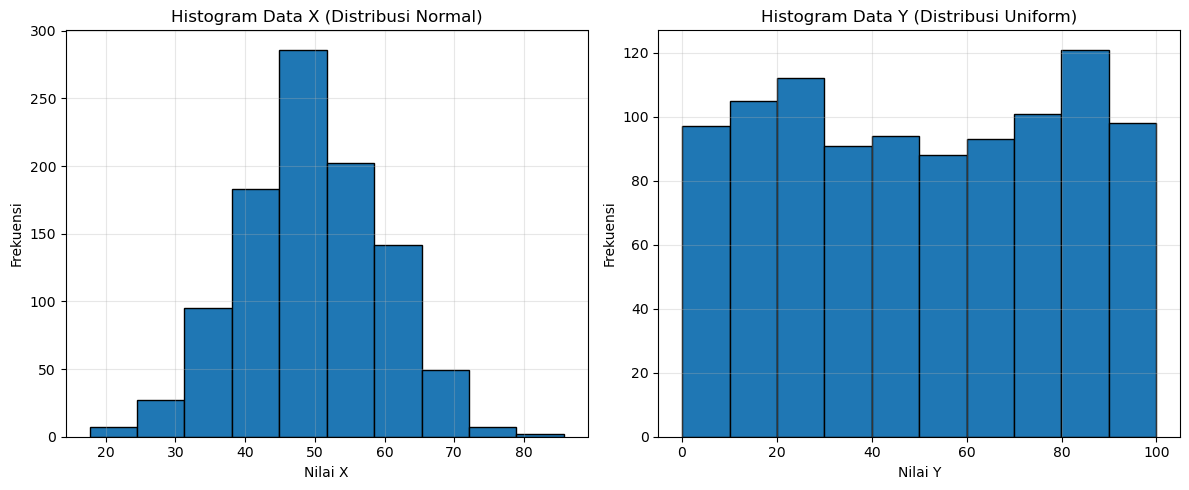

In [83]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram X
ax[0].hist(
    X,
    bins=10,
    edgecolor='black'
)

ax[0].set_title("Histogram Data X (Distribusi Normal)")
ax[0].set_xlabel("Nilai X")
ax[0].set_ylabel("Frekuensi")
ax[0].grid(alpha=0.3)

# Histogram Y
ax[1].hist(
    Y,
    bins=10,
    edgecolor='black'
)

ax[1].set_title("Histogram Data Y (Distribusi Uniform)")
ax[1].set_xlabel("Nilai Y")
ax[1].set_ylabel("Frekuensi")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

 **2. MENGUJI DATA TERHADAP REGRESI LINEAR**

**Regresi Linear Sederhana**

Regresi linear sederhana digunakan untuk mengetahui hubungan antara variabel independen (X) dan variabel dependen (Y), serta memprediksi nilai Y berdasarkan X.

**1. Model Regresi Linear**

Model regresi linear sederhana dinyatakan sebagai:

$$
\hat{y} = a + bX
$$

Keterangan:
- $\hat{y}$ = nilai prediksi
- $a$ = intercept (titik potong)
- $b$ = slope (kemiringan garis)
- $X$ = variabel independen

**2. Koefisien Slope (b)**

$$
b = \frac{\sum (X - \bar{X})(Y - \bar{Y})}{\sum (X - \bar{X})^2}
$$

**3. Intercept (a)**

$$
a = \bar{Y} - b\bar{X}
$$

**4. Koefisien Determinasi (R²)**

Koefisien determinasi digunakan untuk mengukur seberapa besar variasi Y dapat dijelaskan oleh X.

$$
R^2 = r^2
$$

Keterangan:
- $R^2 = 0$ → tidak ada hubungan
- $R^2 = 1$ → hubungan sempurna

**5. Uji Signifikansi Regresi**

Hipotesis:

$$
H_0 : \text{tidak ada hubungan antara X dan Y}
$$

$$
H_1 : \text{ada hubungan antara X dan Y}
$$

Kriteria:

- Jika p-value < 0.05 → hubungan signifikan
- Jika p-value ≥ 0.05 → tidak signifikan

**6. Interpretasi**

- Slope positif → hubungan searah
- Slope negatif → hubungan berlawanan
- Semakin besar $R^2$ → semakin kuat hubungan

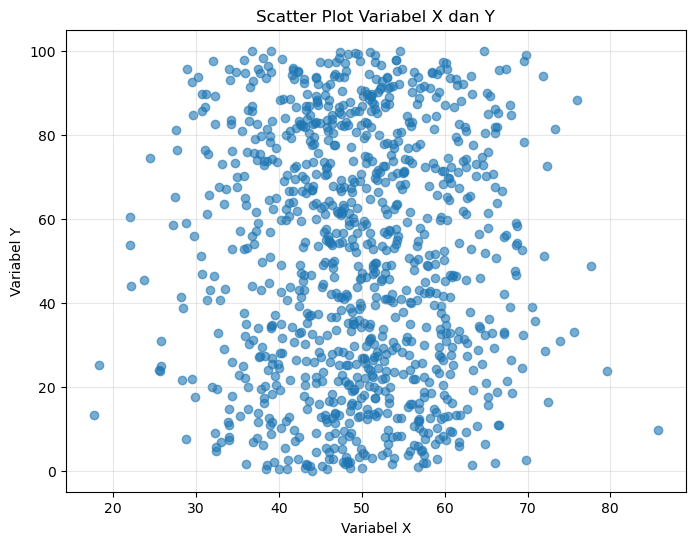

In [84]:
plt.figure(figsize=(8,6))

plt.scatter(
    X,
    Y,
    alpha=0.6
)

plt.title("Scatter Plot Variabel X dan Y")
plt.xlabel("Variabel X")
plt.ylabel("Variabel Y")

plt.grid(alpha=0.3)

plt.show()

In [85]:
X_reg = sm.add_constant(X)

model = sm.OLS(Y, X_reg).fit()

# Koefisien regresi
intercept = model.params[0]
slope = model.params[1]

# Statistik uji
r_square = model.rsquared
p_value = model.pvalues[1]

# Prediksi
Y_pred = model.predict(X_reg)

# Residual
residual = Y - Y_pred

# Mengurutkan data untuk garis regresi
urut = np.argsort(X)

X_sort = X[urut]
Y_pred_sort = Y_pred[urut]

print("="*30)
print("HASIL REGRESI".center(30))
print("="*30)

print(f"Intercept (β₀) : {intercept:.4f}")
print(f"Slope (β₁)     : {slope:.4f}")
print(f"R²             : {r_square:.4f}")
print(f"p-value        : {p_value:.4f}")
print("="*30)

        HASIL REGRESI         
Intercept (β₀) : 53.8666
Slope (β₁)     : -0.0741
R²             : 0.0006
p-value        : 0.4233


In [86]:
from scipy.stats import pearsonr

r, p_corr = pearsonr(X, Y)

print("\n" + "=" * 40)
print("KORELASI PEARSON".center(40))
print("=" * 40)

print(f"Koefisien Korelasi (r) : {r:.4f}")
print(f"p-value                : {p_corr:.4f}")

print("=" * 40)


            KORELASI PEARSON            
Koefisien Korelasi (r) : -0.0253
p-value                : 0.4233


In [87]:
import statsmodels.api as sm

X_reg = sm.add_constant(X)

model = sm.OLS(Y, X_reg).fit()
# print(model.summary())

In [88]:
# ==================================================
# HASIL UJI REGRESI LINEAR
# ==================================================

alpha = 0.05

print("\n" + "=" * 120)
print(" HASIL UJI REGRESI LINEAR".center(120))
print("=" * 120)

# ------------------------------------------
# Persamaan Regresi
# ------------------------------------------

print("\nPersamaan Regresi:")
print(f"Ŷ = {model.params[0]:.4f} + ({model.params[1]:.4f})X")

# ------------------------------------------
# Statistik Uji
# ------------------------------------------

print("\nStatistik Uji:")
print(f"t-statistik : {model.tvalues[1]:.4f}")
print(f"p-value     : {model.pvalues[1]:.4f}")
print(f"F-statistik : {model.fvalue:.4f}")
print(f"R²          : {model.rsquared:.4f}")

# ------------------------------------------
# Hipotesis
# ------------------------------------------

print("\nHipotesis:")
print("H₀ : β₁ = 0 (Tidak terdapat pengaruh linear X terhadap Y)")
print("H₁ : β₁ ≠ 0 (Terdapat pengaruh linear X terhadap Y)")

# ------------------------------------------
# Keputusan
# ------------------------------------------

if model.pvalues[1] < alpha:

    print("\nKeputusan : TOLAK H₀")

    print(
        f"Alasan    : p-value ({model.pvalues[1]:.4f}) "
        f"< α ({alpha}) sehingga koefisien regresi signifikan."
    )

    print(
        "\nKesimpulan : Variabel X memiliki pengaruh linear "
        "yang signifikan terhadap variabel Y."
    )

else:

    print("\nKeputusan : GAGAL TOLAK H₀")

    print(
        f"Alasan    : p-value ({model.pvalues[1]:.4f}) "
        f"> α ({alpha}) sehingga koefisien regresi tidak signifikan."
    )

    print(
        "\nKesimpulan : Variabel X tidak memiliki pengaruh linear "
        "yang signifikan terhadap variabel Y."
    )

# ------------------------------------------
# Interpretasi R²
# ------------------------------------------

print(
    f"\nInterpretasi : Nilai R² sebesar {model.rsquared:.4f} "
    f"menunjukkan bahwa {model.rsquared * 100:.2f}% variasi "
    "pada variabel Y dapat dijelaskan oleh variabel X."
)

print("=" * 120)


                                                HASIL UJI REGRESI LINEAR                                                

Persamaan Regresi:
Ŷ = 53.8666 + (-0.0741)X

Statistik Uji:
t-statistik : -0.8011
p-value     : 0.4233
F-statistik : 0.6417
R²          : 0.0006

Hipotesis:
H₀ : β₁ = 0 (Tidak terdapat pengaruh linear X terhadap Y)
H₁ : β₁ ≠ 0 (Terdapat pengaruh linear X terhadap Y)

Keputusan : GAGAL TOLAK H₀
Alasan    : p-value (0.4233) > α (0.05) sehingga koefisien regresi tidak signifikan.

Kesimpulan : Variabel X tidak memiliki pengaruh linear yang signifikan terhadap variabel Y.

Interpretasi : Nilai R² sebesar 0.0006 menunjukkan bahwa 0.06% variasi pada variabel Y dapat dijelaskan oleh variabel X.


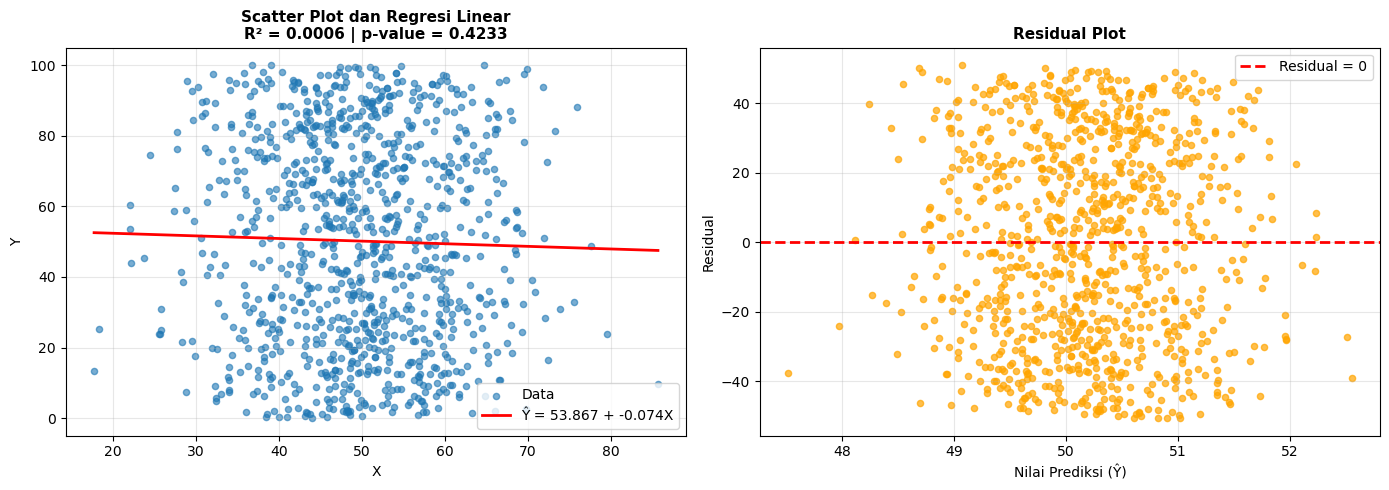

In [89]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------
# Scatter Plot + Garis Regresi
# ------------------------------------------

ax[0].scatter(
    X,
    Y,
    alpha=0.6,
    s=20,
    label="Data"
)

ax[0].plot(
    X_sort,
    Y_pred_sort,
    color="red",
    linewidth=2,
    label=f"Ŷ = {intercept:.3f} + {slope:.3f}X"
)

ax[0].set_title(
    f"Scatter Plot dan Regresi Linear\n"
    f"R² = {r_square:.4f} | p-value = {p_value:.4f}",
    fontsize=11,
    fontweight="bold"
)

ax[0].set_xlabel("X")
ax[0].set_ylabel("Y")

ax[0].legend()
ax[0].grid(True, alpha=0.3)

# ------------------------------------------
# Residual Plot
# ------------------------------------------

ax[1].scatter(
    Y_pred,
    residual,
    color="orange",
    alpha=0.7,
    s=20
)

ax[1].axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Residual = 0"
)

ax[1].set_title(
    "Residual Plot",
    fontsize=11,
    fontweight="bold"
)

ax[1].set_xlabel("Nilai Prediksi (Ŷ)")
ax[1].set_ylabel("Residual")

ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 **3. MENGUJI DATA DENGAN UJI DISTRIBUSI**

**Uji Distribusi Data (X Normal & Y Uniform)**

Dalam penelitian ini digunakan dua variabel:
- X ~ Distribusi Normal
- Y ~ Distribusi Uniform

Uji distribusi bertujuan untuk mengetahui kesesuaian data terhadap distribusi teoritis menggunakan beberapa metode statistik.

**1. Uji Kolmogorov-Smirnov (KS Test)**

Uji Kolmogorov-Smirnov digunakan untuk mengukur jarak maksimum antara distribusi empiris data dengan distribusi teoritis.

Rumus umum:

$$
D = \sup |F_n(x) - F(x)|
$$

Untuk X (Normal):

$$
D_X = \sup |F_X(x) - F_{Normal}(x)|
$$

Untuk Y (Uniform):

$$
D_Y = \sup |F_Y(y) - F_{Uniform}(y)|
$$

Keterangan:
- $F_n(x)$ = fungsi distribusi empiris  
- $F(x)$ = fungsi distribusi teoritis  
- $\sup$ = nilai maksimum selisih  

**2. Uji Anderson-Darling**

Uji Anderson-Darling digunakan untuk menguji kesesuaian distribusi dengan memberikan bobot lebih pada bagian ekor distribusi.

Statistik uji:

$$
A^2 = -n - \frac{1}{n} \sum_{i=1}^{n} (2i-1)\left[\ln F(x_i) + \ln(1 - F(x_{n+1-i}))\right]
$$

Keterangan:
- $n$ = jumlah data  
- $F(x)$ = fungsi distribusi kumulatif  

**3. Uji Shapiro-Wilk (Normalitas)**

Uji Shapiro-Wilk digunakan khusus untuk menguji apakah data berdistribusi normal.

Untuk X (Normal):

$$
H_0 : X \sim N(\mu, \sigma^2)
$$

$$
H_1 : X \not\sim N(\mu, \sigma^2)
$$

Statistik uji:

$$
W = \frac{\left(\sum a_i x_{(i)}\right)^2}{\sum (x_i - \bar{x})^2}
$$

**Catatan penting:**
Uji Shapiro-Wilk hanya digunakan untuk normalitas, sehingga hanya relevan untuk variabel X.

**4. Uji Chi-Square (Goodness of Fit)**

Uji Chi-Square digunakan untuk membandingkan frekuensi observasi dengan frekuensi harapan dalam suatu distribusi.

Rumus:

$$
\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}
$$

Untuk X (Normal):

Digunakan untuk menguji kesesuaian distribusi normal.

Untuk Y (Uniform):

Digunakan untuk menguji kesesuaian distribusi uniform.

Keterangan:
- $O_i$ = frekuensi observasi  
- $E_i$ = frekuensi harapan  
- Data harus dikelompokkan dalam kelas (bin/interval)  


**5. Kriteria Pengambilan Keputusan (Semua Uji)**

- Jika p-value > 0.05 → gagal tolak H₀ (data sesuai distribusi)
- Jika p-value ≤ 0.05 → tolak H₀ (data tidak sesuai distribusi)

In [91]:
# ===========================
# UJI KOLMOGOROV-SMIRNOV
# ===========================

from scipy.stats import kstest

alpha = 0.05

ks_stat_x, ks_pvalue_x = kstest(
    X,
    'norm',
    args=(np.mean(X), np.std(X, ddof=1))
)

print("\n" + "=" *50)
print(" UJI KOLMOGOROV-SMIRNOV (X) ".center(50))
print("=" *50)

print(f"\nStatistik Uji : {ks_stat_x:.4f}")
print(f"p-value       : {ks_pvalue_x:.4f}")

if ks_pvalue_x > alpha:

    print("\nKeputusan : GAGAL TOLAK H₀")

    print(
        "Kesimpulan : Data X berdistribusi normal"
    )

else:

    print("\nKeputusan : TOLAK H₀")

    print(
        "Kesimpulan : Data X tidak berdistribusi normal"
    )

print("=" * 50)


            UJI KOLMOGOROV-SMIRNOV (X)            

Statistik Uji : 0.0177
p-value       : 0.9061

Keputusan : GAGAL TOLAK H₀
Kesimpulan : Data X berdistribusi normal


In [92]:
# ==========================
# UJI ANDERSON-DARLING
# ==========================

from scipy.stats import anderson

ad_result_x = anderson(X, dist='norm')

print("\n" + "=" * 50)
print(" UJI ANDERSON-DARLING (X) ".center(50))
print("=" * 50)

print(f"\nStatistik Uji : {ad_result_x.statistic:.4f}")

critical = ad_result_x.critical_values[2]
sig_level = ad_result_x.significance_level[2]

print(f"Critical Value ({sig_level}%) : {critical:.4f}")

if ad_result_x.statistic < critical:

    print("\nKeputusan : GAGAL TOLAK H₀")

    print(
        "Kesimpulan : Data X berdistribusi normal"
    )

else:

    print("\nKeputusan : TOLAK H₀")

    print(
        "Kesimpulan : Data X tidak berdistribusi normal"
    )

print("=" * 50)


             UJI ANDERSON-DARLING (X)             

Statistik Uji : 0.2981
Critical Value (5.0%) : 0.7840

Keputusan : GAGAL TOLAK H₀
Kesimpulan : Data X berdistribusi normal


In [93]:
# =======================
#  UJI SHAPIRO-WILK
# =======================

from scipy.stats import shapiro

sw_stat_x, sw_pvalue_x = shapiro(X)

print("\n" + "=" * 50)
print(" UJI SHAPIRO-WILK (X) ".center(50))
print("=" * 50)

print(f"\nStatistik Uji : {sw_stat_x:.4f}")
print(f"p-value       : {sw_pvalue_x:.4f}")

if sw_pvalue_x > alpha:

    print("\nKeputusan : GAGAL TOLAK H₀")

    print(
        "Kesimpulan : Data X berdistribusi normal"
    )

else:

    print("\nKeputusan : TOLAK H₀")

    print(
        "Kesimpulan : Data X tidak berdistribusi normal"
    )

print("=" * 50)


               UJI SHAPIRO-WILK (X)               

Statistik Uji : 0.9990
p-value       : 0.8966

Keputusan : GAGAL TOLAK H₀
Kesimpulan : Data X berdistribusi normal


In [94]:
# ================
# UJI CHI-SQUARE
# ================

from scipy.stats import chisquare, norm

# Frekuensi observasi
obs_freq, bins = np.histogram(X, bins=10)

# Frekuensi harapan
cdf = norm.cdf(
    bins,
    loc=np.mean(X),
    scale=np.std(X, ddof=1)
)

expected = len(X) * np.diff(cdf)

# Penyesuaian agar total sama
expected = expected * (obs_freq.sum() / expected.sum())

chi_stat_x, chi_pvalue_x = chisquare(
    f_obs=obs_freq,
    f_exp=expected
)

print("\n" + "=" * 50)
print(" UJI CHI-SQUARE (X) ".center(50))
print("=" * 50)

print(f"\nStatistik Uji : {chi_stat_x:.4f}")
print(f"p-value       : {chi_pvalue_x:.4f}")

if chi_pvalue_x > alpha:

    print("\nKeputusan : GAGAL TOLAK H₀")

    print(
        "Kesimpulan : Data X berdistribusi normal"
    )

else:

    print("\nKeputusan : TOLAK H₀")

    print(
        "Kesimpulan : Data X tidak berdistribusi normal"
    )

print("=" * 50)


                UJI CHI-SQUARE (X)                

Statistik Uji : 9.4706
p-value       : 0.3950

Keputusan : GAGAL TOLAK H₀
Kesimpulan : Data X berdistribusi normal


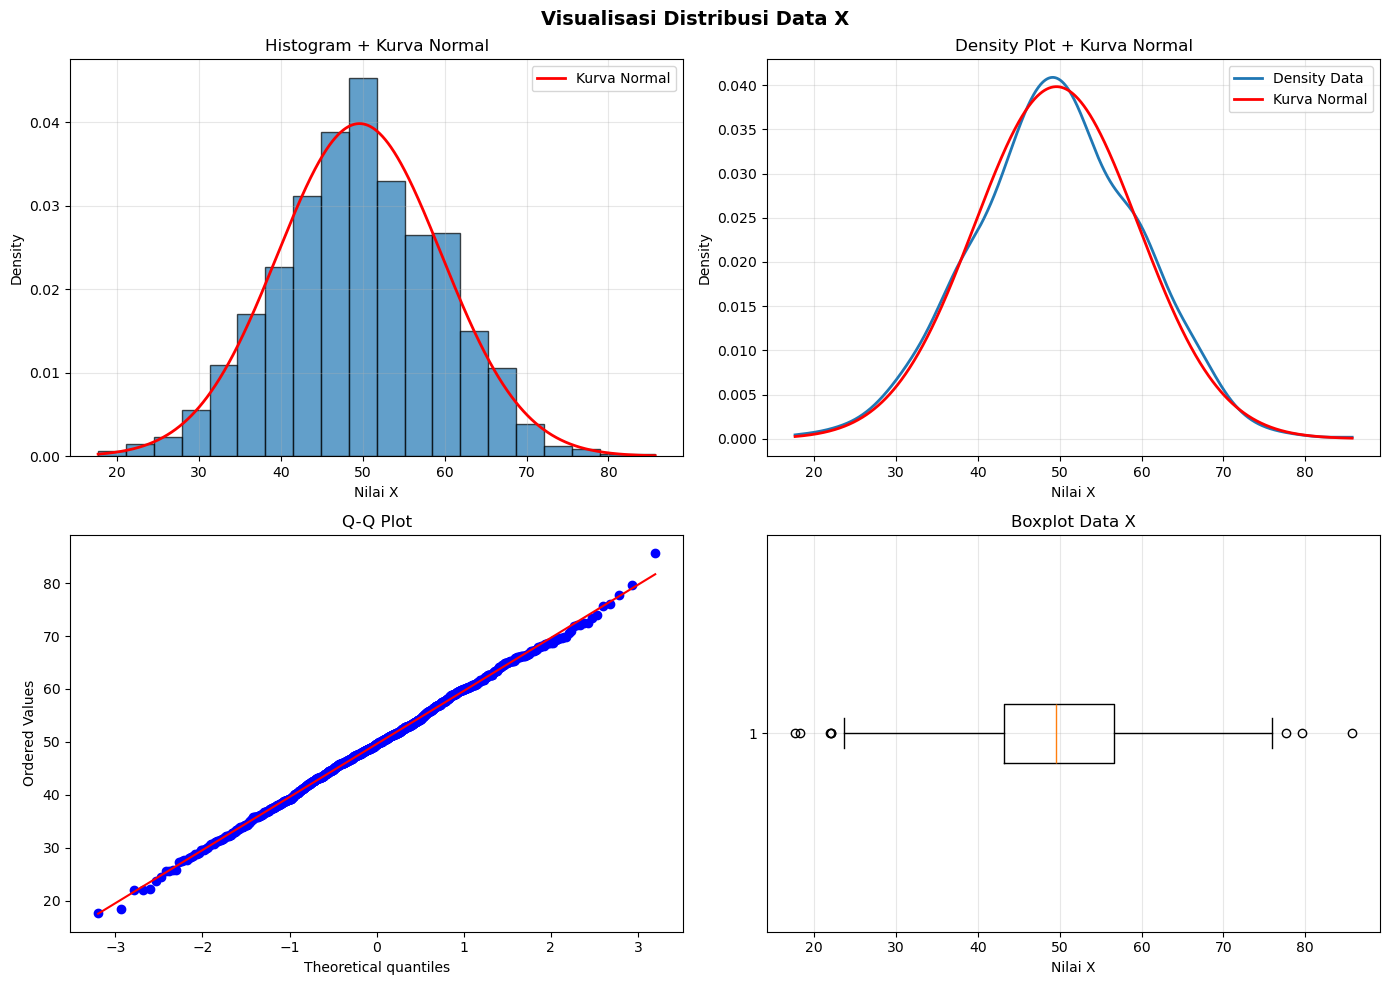

In [102]:
# ==============================
# 3.1 VISUALISASI DISTRIBUSI X
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde, probplot

# Statistik X
mean_x = np.mean(X)
std_x = np.std(X, ddof=1)

# Membuat figure 2x2
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# =============================
# 1. Histogram + Kurva Normal
# =============================

ax[0,0].hist(
    X,
    bins=20,
    density=True,
    edgecolor='black',
    alpha=0.7
)

x_range = np.linspace(X.min(), X.max(), 1000)

ax[0,0].plot(
    x_range,
    norm.pdf(x_range, mean_x, std_x),
    color='red',
    linewidth=2,
    label='Kurva Normal'
)

ax[0,0].set_title("Histogram + Kurva Normal")
ax[0,0].set_xlabel("Nilai X")
ax[0,0].set_ylabel("Density")
ax[0,0].legend()
ax[0,0].grid(alpha=0.3)

# ================================
# 2. Density Plot + Kurva Normal 
# ================================

kde = gaussian_kde(X)

ax[0,1].plot(
    x_range,
    kde(x_range),
    linewidth=2,
    label="Density Data"
)

ax[0,1].plot(
    x_range,
    norm.pdf(x_range, mean_x, std_x),
    color='red',
    linewidth=2,
    label="Kurva Normal"
)

ax[0,1].set_title("Density Plot + Kurva Normal")
ax[0,1].set_xlabel("Nilai X")
ax[0,1].set_ylabel("Density")
ax[0,1].legend()
ax[0,1].grid(alpha=0.3)

# =============
# 3. Q-Q Plot
# =============

probplot(
    X,
    dist="norm",
    plot=ax[1,0]
)

ax[1,0].set_title("Q-Q Plot")

# ============
# 4. Boxplot
# ============

ax[1,1].boxplot(
    X,
    vert=False
)

ax[1,1].set_title("Boxplot Data X")
ax[1,1].set_xlabel("Nilai X")
ax[1,1].grid(alpha=0.3)


plt.suptitle(
    "Visualisasi Distribusi Data X",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [96]:
# =======================
# UJI KOLMOGOROV-SMIRNOV
# =======================

from scipy.stats import kstest

alpha = 0.05

ks_stat_y, ks_pvalue_y = kstest(
    Y,
    'norm',
    args=(np.mean(Y), np.std(Y, ddof=1))
)

print("\n" + "=" * 50)
print(" UJI KOLMOGOROV-SMIRNOV (Y) ".center(50))
print("=" * 50)

print(f"\nStatistik Uji : {ks_stat_y:.4f}")
print(f"p-value       : {ks_pvalue_y:.4f}")

if ks_pvalue_y > alpha:

    print("\nKeputusan : GAGAL TOLAK H₀")
    print("Kesimpulan : Data Y berdistribusi normal.")

else:

    print("\nKeputusan : TOLAK H₀")
    print("Kesimpulan : Data Y tidak berdistribusi normal")

print("=" * 50)


            UJI KOLMOGOROV-SMIRNOV (Y)            

Statistik Uji : 0.0727
p-value       : 0.0000

Keputusan : TOLAK H₀
Kesimpulan : Data Y tidak berdistribusi normal


In [97]:
# =====================
# UJI ANDERSON-DARLING
# =====================

from scipy.stats import anderson

ad_result_y= anderson(Y, dist='norm')

print("\n" + "=" * 50)
print(" UJI ANDERSON-DARLING (Y) ".center(50))
print("=" * 50)

print(f"\nStatistik Uji : {ad_result_y.statistic:.4f}")

critical = ad_result_y.critical_values[2]
sig_level = ad_result_y.significance_level[2]

print(f"Critical Value ({sig_level}%) : {critical:.4f}")

if ad_result_y.statistic < critical:

    print("\nKeputusan : GAGAL TOLAK H₀")
    print("Kesimpulan : Data Y berdistribusi normal.")

else:

    print("\nKeputusan : TOLAK H₀")
    print("Kesimpulan : Data Y tidak berdistribusi normal")

print("=" * 50)


             UJI ANDERSON-DARLING (Y)             

Statistik Uji : 14.5597
Critical Value (5.0%) : 0.7840

Keputusan : TOLAK H₀
Kesimpulan : Data Y tidak berdistribusi normal


In [98]:
# ====================
# UJI SHAPIRO-WILK
# ====================

from scipy.stats import shapiro

sw_stat_y, sw_pvalue_y = shapiro(Y)

print("\n" + "=" * 50)
print(" UJI SHAPIRO-WILK (Y) ".center(50))
print("=" * 50)

print(f"\nStatistik Uji : {sw_stat_y:.4f}")
print(f"p-value       : {sw_pvalue_y:.4f}")

if sw_pvalue_y > alpha:

    print("\nKeputusan : GAGAL TOLAK H₀")
    print("Kesimpulan : Data Y berdistribusi normal.")

else:

    print("\nKeputusan : TOLAK H₀")
    print("Kesimpulan : Data Y tidak berdistribusi normal")

print("=" * 50)


               UJI SHAPIRO-WILK (Y)               

Statistik Uji : 0.9472
p-value       : 0.0000

Keputusan : TOLAK H₀
Kesimpulan : Data Y tidak berdistribusi normal


In [99]:
# ================
# UJI CHI-SQUARE
# ================

from scipy.stats import chisquare, norm

obs_freq, bins = np.histogram(Y, bins=10)

cdf = norm.cdf(
    bins,
    loc=np.mean(Y),
    scale=np.std(Y, ddof=1)
)

expected = len(Y) * np.diff(cdf)

expected = expected * (obs_freq.sum() / expected.sum())

chi_stat_y, chi_pvalue_y = chisquare(
    f_obs=obs_freq,
    f_exp=expected
)

print("\n" + "=" * 50)
print(" UJI CHI-SQUARE (Y) ".center(50))
print("=" * 50)

print(f"\nStatistik Uji : {chi_stat_y:.4f}")
print(f"p-value       : {chi_pvalue_y:.4f}")

if chi_pvalue_y > alpha:

    print("\nKeputusan : GAGAL TOLAK H₀")
    print("Kesimpulan : Data Y berdistribusi normal.")

else:

    print("\nKeputusan : TOLAK H₀")
    print("Kesimpulan : Data Y tidak berdistribusi normal")

print("=" * 50)


                UJI CHI-SQUARE (Y)                

Statistik Uji : 224.5951
p-value       : 0.0000

Keputusan : TOLAK H₀
Kesimpulan : Data Y tidak berdistribusi normal


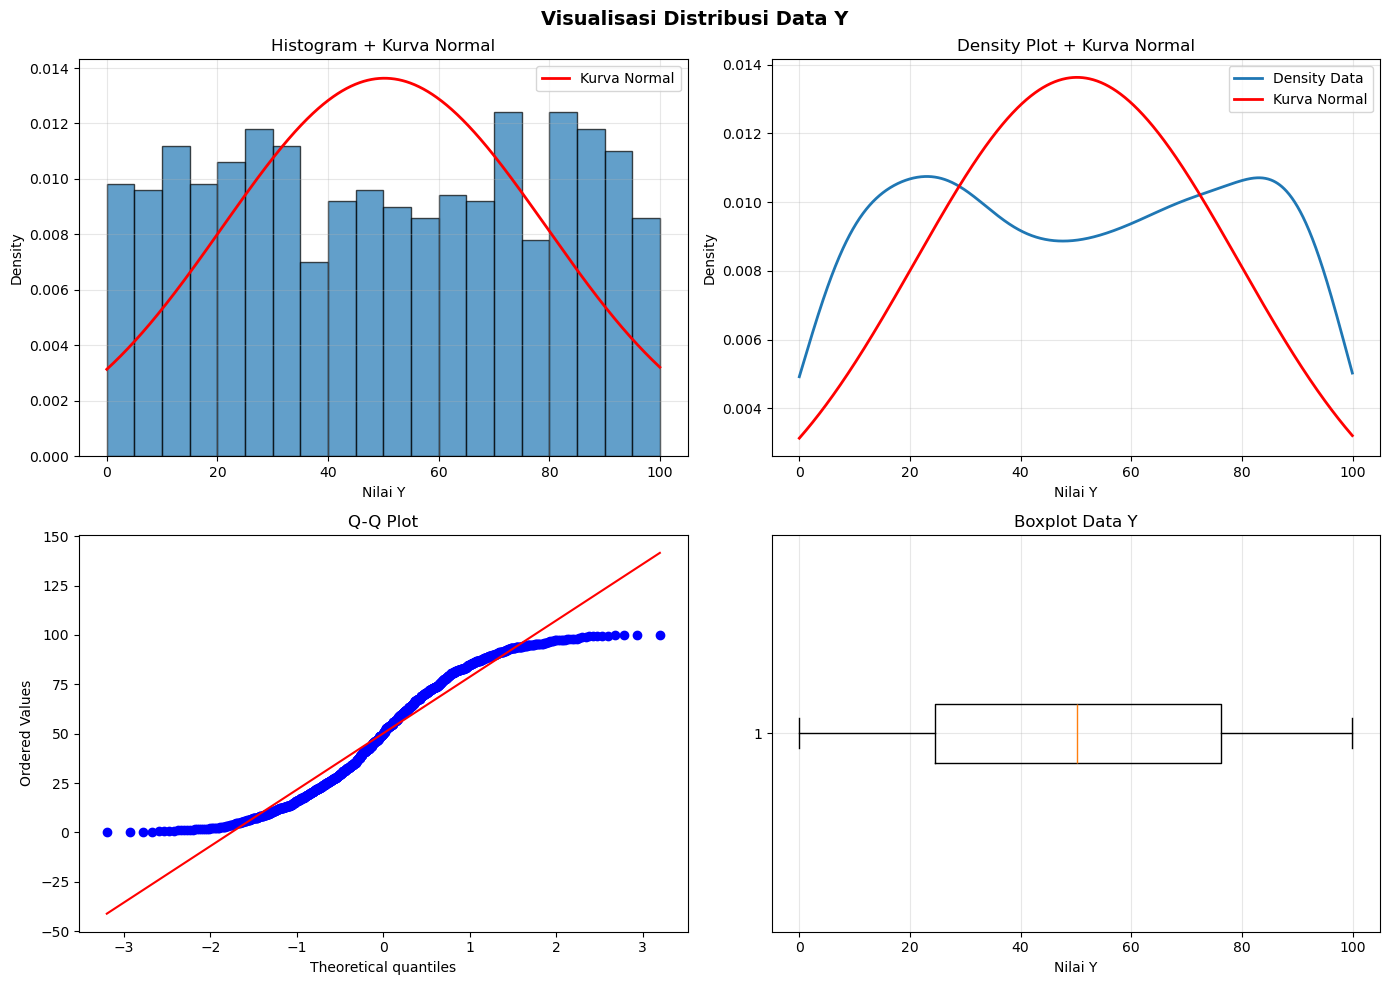

In [103]:
# ==================================================
# 3.3 VISUALISASI DISTRIBUSI Y
# ==================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde, probplot

# Statistik Y
mean_y = np.mean(Y)
std_y = np.std(Y, ddof=1)

# Membuat figure 2x2
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# ==================================================
# 1. Histogram + Kurva Normal
# ==================================================

ax[0,0].hist(
    Y,
    bins=20,
    density=True,
    edgecolor='black',
    alpha=0.7
)

y_range = np.linspace(Y.min(), Y.max(), 1000)

ax[0,0].plot(
    y_range,
    norm.pdf(y_range, mean_y, std_y),
    color='red',
    linewidth=2,
    label='Kurva Normal'
)

ax[0,0].set_title("Histogram + Kurva Normal")
ax[0,0].set_xlabel("Nilai Y")
ax[0,0].set_ylabel("Density")
ax[0,0].legend()
ax[0,0].grid(alpha=0.3)

# ==================================================
# 2. Density Plot + Kurva Normal Teoritis
# ==================================================

kde = gaussian_kde(Y)

ax[0,1].plot(
    y_range,
    kde(y_range),
    linewidth=2,
    label="Density Data"
)

ax[0,1].plot(
    y_range,
    norm.pdf(y_range, mean_y, std_y),
    color='red',
    linewidth=2,
    label="Kurva Normal"
)

ax[0,1].set_title("Density Plot + Kurva Normal")
ax[0,1].set_xlabel("Nilai Y")
ax[0,1].set_ylabel("Density")
ax[0,1].legend()
ax[0,1].grid(alpha=0.3)

# ==================================================
# 3. Q-Q Plot
# ==================================================

probplot(
    Y,
    dist="norm",
    plot=ax[1,0]
)

ax[1,0].set_title("Q-Q Plot")

# ==================================================
# 4. Boxplot
# ==================================================

ax[1,1].boxplot(
    Y,
    vert=False
)

ax[1,1].set_title("Boxplot Data Y")
ax[1,1].set_xlabel("Nilai Y")
ax[1,1].grid(alpha=0.3)

# ==================================================
# TAMPILKAN
# ==================================================

plt.suptitle(
    "Visualisasi Distribusi Data Y",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

 **4. ANALISIS DAN KESIMPULAN**

In [100]:
alpha = 0.05

print("\n" + "=" *50)
print("ANALISIS UJI DISTRIBUSI".center(50))
print("=" *50)

print("\nKOLMOGOROV-SMIRNOV")
print(f"X (Normal)  : {'Normal' if ks_pvalue_x > alpha else 'Tidak Normal'} | p-value = {ks_pvalue_x:.6f}")
print(f"Y (Uniform) : {'Normal' if ks_pvalue_y > alpha else 'Tidak Normal'} | p-value = {ks_pvalue_y:.6f}")
print("\n" + "=" *50)

print("\nANDERSON-DARLING")
print(f"X (Normal)  : {'Normal' if ad_result_x.statistic < ad_result_x.critical_values[2] else 'Tidak Normal'} | stat = {ad_result_x.statistic:.6f}")
print(f"Y (Uniform) : {'Normal' if ad_result_y.statistic < ad_result_y.critical_values[2] else 'Tidak Normal'} | stat = {ad_result_y.statistic:.6f}")
print("\n" + "=" *50)

print("\nSHAPIRO-WILK")
print(f"X (Normal)  : {'Normal' if sw_pvalue_x > alpha else 'Tidak Normal'} | p-value = {sw_pvalue_x:.6f}")
print(f"Y (Uniform) : {'Normal' if sw_pvalue_y > alpha else 'Tidak Normal'} | p-value = {sw_pvalue_y:.6f}")
print("\n" + "=" *50)

print("\nCHI-SQUARE")
print(f"X (Normal)  : {'Normal' if chi_pvalue_x > alpha else 'Tidak Normal'} | p-value = {chi_pvalue_x:.6f}")
print(f"Y (Uniform) : {'Normal' if chi_pvalue_y > alpha else 'Tidak Normal'} | p-value = {chi_pvalue_y:.6f}")
print("\n" + "=" *50)


             ANALISIS UJI DISTRIBUSI              

KOLMOGOROV-SMIRNOV
X (Normal)  : Normal | p-value = 0.906096
Y (Uniform) : Tidak Normal | p-value = 0.000048


ANDERSON-DARLING
X (Normal)  : Normal | stat = 0.298116
Y (Uniform) : Tidak Normal | stat = 14.559700


SHAPIRO-WILK
X (Normal)  : Normal | p-value = 0.896605
Y (Uniform) : Tidak Normal | p-value = 0.000000


CHI-SQUARE
X (Normal)  : Normal | p-value = 0.395011
Y (Uniform) : Tidak Normal | p-value = 0.000000



In [101]:
print("\n" + "=" * 145)
print("KESIMPULAN AKHIR".center(145))
print("=" * 145)

print(
    "\n1. Data X cenderung memenuhi asumsi normalitas "
    "berdasarkan hasil pengujian Kolmogorov-Smirnov, "
    "Anderson-Darling, Shapiro-Wilk, dan Chi-Square."
)

print(
    "\n2. Data Y tidak memenuhi asumsi normalitas "
    "karena dibangkitkan dari distribusi Uniform."
)

print(
    "\n3. Hasil visualisasi berupa Histogram, Density Plot, "
    "Q-Q Plot, dan Boxplot mendukung hasil pengujian statistik."
)

print(
    "\n4. Secara keseluruhan, data X dapat dianggap berdistribusi "
    "normal, sedangkan data Y tidak berdistribusi normal."
)

print("=" * 145)


                                                                 KESIMPULAN AKHIR                                                                

1. Data X cenderung memenuhi asumsi normalitas berdasarkan hasil pengujian Kolmogorov-Smirnov, Anderson-Darling, Shapiro-Wilk, dan Chi-Square.

2. Data Y tidak memenuhi asumsi normalitas karena dibangkitkan dari distribusi Uniform.

3. Hasil visualisasi berupa Histogram, Density Plot, Q-Q Plot, dan Boxplot mendukung hasil pengujian statistik.

4. Secara keseluruhan, data X dapat dianggap berdistribusi normal, sedangkan data Y tidak berdistribusi normal.
